# TON_IoT IDS Training Notebook

This notebook retrains the IDS pipeline for the **TON_IoT** network dataset and follows a CIC-style workflow with:
- schema audit and cleaning
- robust preprocessing
- baseline and tuned model comparison
- deep evaluation (confusion matrix, ROC/PR, per-class metrics)
- model interpretation
- artifact export for reuse

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)

RANDOM_STATE = 42
DATA_PATH = '../data/ton_iot/train_test_network.csv'
ARTIFACT_DIR = '../models/ton_iot'
FIG_DIR = '../figures/ton_iot'
os.makedirs(ARTIFACT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

sns.set_theme(style='whitegrid')

## 1) Load TON_IoT Data and Audit Schema
Load `train_test_network.csv`, then inspect shape, dtypes, null profile, unique counts, and class distribution.

In [2]:
df_raw = pd.read_csv(DATA_PATH)

print('Shape:', df_raw.shape)
print('\nDtypes (top 20):')
print(df_raw.dtypes.head(20))

null_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)
print('\nTop 20 null % columns:')
print(null_pct.head(20))

unique_counts = df_raw.nunique(dropna=False).sort_values(ascending=False)
print('\nTop 20 high-cardinality columns:')
print(unique_counts.head(20))

print('\n`label` distribution:')
print(df_raw['label'].value_counts(dropna=False).head(20))

print('\n`type` distribution:')
print(df_raw['type'].value_counts(dropna=False).head(20))

Shape: (211043, 44)

Dtypes (top 20):
src_ip              str
src_port          int64
dst_ip              str
dst_port          int64
proto               str
service             str
duration        float64
src_bytes         int64
dst_bytes         int64
conn_state          str
missed_bytes      int64
src_pkts          int64
src_ip_bytes      int64
dst_pkts          int64
dst_ip_bytes      int64
dns_query           str
dns_qclass        int64
dns_qtype         int64
dns_rcode         int64
dns_AA              str
dtype: object

Top 20 null % columns:
src_ip          0.0
src_port        0.0
dst_ip          0.0
dst_port        0.0
proto           0.0
service         0.0
duration        0.0
src_bytes       0.0
dst_bytes       0.0
conn_state      0.0
missed_bytes    0.0
src_pkts        0.0
src_ip_bytes    0.0
dst_pkts        0.0
dst_ip_bytes    0.0
dns_query       0.0
dns_qclass      0.0
dns_qtype       0.0
dns_rcode       0.0
dns_AA          0.0
dtype: float64

Top 20 high-cardinality colu

## 2) Clean Placeholder Values and Cast Feature Types
Replace placeholder symbols (`-`) with nulls, coerce numeric fields safely, and normalize categorical text fields.

In [3]:
df = df_raw.copy()

# Normalize placeholder tokens
for token in ['-', ' -', '- ', 'None', 'none', 'N/A', 'na', '']:
    df.replace(token, np.nan, inplace=True)

# Candidate identifier columns (drop to reduce leakage/high-cardinality noise)
id_like_cols = ['src_ip', 'dst_ip']
id_like_cols = [c for c in id_like_cols if c in df.columns]

# Safe numeric coercion on columns that are expected mostly numeric
for col in df.columns:
    if col in ['label', 'type']:
        continue
    as_num = pd.to_numeric(df[col], errors='coerce')
    numeric_ratio = as_num.notna().mean()
    if numeric_ratio >= 0.70:
        df[col] = as_num
    else:
        df[col] = df[col].astype(str).str.strip().str.lower()
        df[col] = df[col].replace('nan', np.nan)

if id_like_cols:
    df = df.drop(columns=id_like_cols)

print('Cleaned shape:', df.shape)
print('Dropped ID-like columns:', id_like_cols)
print('\nDtypes summary after cleaning:')
print(df.dtypes.value_counts())

Cleaned shape: (211043, 42)
Dropped ID-like columns: ['src_ip', 'dst_ip']

Dtypes summary after cleaning:
str        25
int64      16
float64     1
Name: count, dtype: int64


## 3) Define Target Strategy (Binary `label` vs Multi-class `type`)
If `label` is not informative enough for this IDS objective, switch target to `type`.

In [4]:
label_nunique = df['label'].nunique(dropna=True) if 'label' in df.columns else 0
label_majority = df['label'].value_counts(normalize=True, dropna=True).iloc[0] if 'label' in df.columns else 1.0

target_col = 'label'
if ('type' in df.columns) and (label_nunique <= 2 or label_majority > 0.98):
    target_col = 'type'

print('Target selected:', target_col)
if 'label' in df.columns:
    print('`label` unique classes:', label_nunique, '| majority ratio:', round(label_majority, 4))
print('\nTarget distribution (top 20):')
print(df[target_col].value_counts(dropna=False).head(20))

# Keep rows with known target
df = df[df[target_col].notna()].copy()

y_encoder = LabelEncoder()
y = y_encoder.fit_transform(df[target_col].astype(str))
X = df.drop(columns=[target_col])

# If both label and type remain in features, drop the non-target one to avoid leakage
for candidate in ['label', 'type']:
    if candidate in X.columns and candidate != target_col:
        X = X.drop(columns=[candidate])

print('\nFinal X shape:', X.shape)
print('Encoded classes:', list(y_encoder.classes_)[:20], '...')

Target selected: type
`label` unique classes: 2 | majority ratio: 0.7631

Target distribution (top 20):
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
ransomware    20000
scanning      20000
xss           20000
mitm           1043
Name: count, dtype: int64

Final X shape: (211043, 40)
Encoded classes: ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss'] ...


## 4) Split Data with Stratification and Leakage Checks
Create train/validation/test partitions with fixed seed and verify split integrity.

In [5]:
# Optional sampling to keep notebook fast/reproducible on large ..\data
MAX_ROWS = 250_000
if len(X) > MAX_ROWS:
    keep_idx = np.random.RandomState(RANDOM_STATE).choice(np.arange(len(X)), size=MAX_ROWS, replace=False)
    X = X.iloc[keep_idx].reset_index(drop=True)
    y = y[keep_idx]

indices = np.arange(len(X))

X_trainval, X_test, y_trainval, y_test, idx_trainval, idx_test = train_test_split(
    X, y, indices, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X_trainval, y_trainval, idx_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y_trainval
)

print('Train/Val/Test shapes:', X_train.shape, X_val.shape, X_test.shape)
print('Leakage check overlaps (should be 0):')
print('train∩val =', len(set(idx_train).intersection(set(idx_val))))
print('train∩test =', len(set(idx_train).intersection(set(idx_test))))
print('val∩test =', len(set(idx_val).intersection(set(idx_test))))

Train/Val/Test shapes: (126625, 40) (42209, 40) (42209, 40)
Leakage check overlaps (should be 0):
train∩val = 0
train∩test = 0
val∩test = 0


## 5) Build a Reproducible Preprocessing Pipeline
Create a `ColumnTransformer` with numeric/categorical branches and reuse it consistently across models.

In [6]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler(with_mean=False))
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features),
])

print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))

Numeric features: 16
Categorical features: 24


## 6) Train Baseline Models and Compare Metrics
Train baseline classifiers and compare weighted-F1, macro-F1, precision, recall, and balanced accuracy.

In [7]:
baseline_models = {
    'LogisticRegression': LogisticRegression(max_iter=400, class_weight='balanced', n_jobs=None),
    'RandomForest': RandomForestClassifier(
        n_estimators=150, max_depth=20, min_samples_split=4,
        class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=200, max_depth=25, min_samples_split=4,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
}

baseline_rows = []
fitted_baselines = {}

for name, model in baseline_models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    pipe.fit(X_train, y_train)
    pred_val = pipe.predict(X_val)

    row = {
        'Model': name,
        'F1_weighted': f1_score(y_val, pred_val, average='weighted', zero_division=0),
        'F1_macro': f1_score(y_val, pred_val, average='macro', zero_division=0),
        'Precision_weighted': precision_score(y_val, pred_val, average='weighted', zero_division=0),
        'Recall_weighted': recall_score(y_val, pred_val, average='weighted', zero_division=0),
        'Balanced_Accuracy': balanced_accuracy_score(y_val, pred_val),
    }
    baseline_rows.append(row)
    fitted_baselines[name] = pipe

baseline_df = pd.DataFrame(baseline_rows).sort_values('F1_weighted', ascending=False)
display(baseline_df)

best_baseline_name = baseline_df.iloc[0]['Model']
best_baseline_pipe = fitted_baselines[best_baseline_name]
print('Best baseline:', best_baseline_name)

,Model,F1_weighted,F1_macro,Precision_weighted,Recall_weighted,Balanced_Accuracy
1,RandomForest,0.986688,0.957181,0.987915,0.986117,0.982172
2,ExtraTrees,0.941570,0.889952,0.950332,0.939089,0.928891
0,LogisticRegression,0.833509,0.792696,0.848218,0.832524,0.841380


Best baseline: RandomForest


## 7) Tune the Best Model and Handle Class Imbalance
Use class weights and randomized hyperparameter search on the best baseline family.

In [8]:
if best_baseline_name == 'LogisticRegression':
    search_model = LogisticRegression(max_iter=600, class_weight='balanced')
    param_dist = {
        'model__C': np.logspace(-2, 1, 8),
        'model__solver': ['lbfgs', 'saga'],
    }
elif best_baseline_name == 'RandomForest':
    search_model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    param_dist = {
        'model__n_estimators': [120, 180, 240],
        'model__max_depth': [12, 18, 25, None],
        'model__min_samples_split': [2, 4, 8],
        'model__min_samples_leaf': [1, 2, 4],
        'model__class_weight': ['balanced', 'balanced_subsample', None],
    }
else:
    search_model = ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    param_dist = {
        'model__n_estimators': [150, 220, 300],
        'model__max_depth': [15, 25, 35, None],
        'model__min_samples_split': [2, 4, 8],
        'model__min_samples_leaf': [1, 2, 4],
        'model__class_weight': ['balanced', None],
    }

tune_pipe = Pipeline([
    ('prep', preprocess),
    ('model', search_model)
])

search = RandomizedSearchCV(
    estimator=tune_pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1_weighted',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

print('Best search score:', search.best_score_)
print('Best params:', search.best_params_)

val_pred_best = best_model.predict(X_val)
print('\nValidation weighted F1 (tuned):', f1_score(y_val, val_pred_best, average='weighted', zero_division=0))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best search score: 0.9883782442867451
Best params: {'model__n_estimators': 180, 'model__min_samples_split': 8, 'model__min_samples_leaf': 1, 'model__max_depth': None, 'model__class_weight': 'balanced_subsample'}

Validation weighted F1 (tuned): 0.9890050124866892


## 8) Evaluate with Confusion Matrix, ROC/PR, and Per-Class Scores
Report full classification diagnostics on held-out test data.

Test weighted F1: 0.9889271546027687
Test macro F1: 0.9627094156172851
Test balanced accuracy: 0.9820264354066985

Classification Report:

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      4000
        ddos       0.99      0.98      0.98      4000
         dos       1.00      0.98      0.99      4000
   injection       0.97      0.97      0.97      4000
        mitm       0.59      0.93      0.73       209
      normal       1.00      1.00      1.00     10000
    password       1.00      0.99      0.99      4000
  ransomware       1.00      1.00      1.00      4000
    scanning       0.99      0.99      0.99      4000
         xss       0.98      0.98      0.98      4000

    accuracy                           0.99     42209
   macro avg       0.95      0.98      0.96     42209
weighted avg       0.99      0.99      0.99     42209



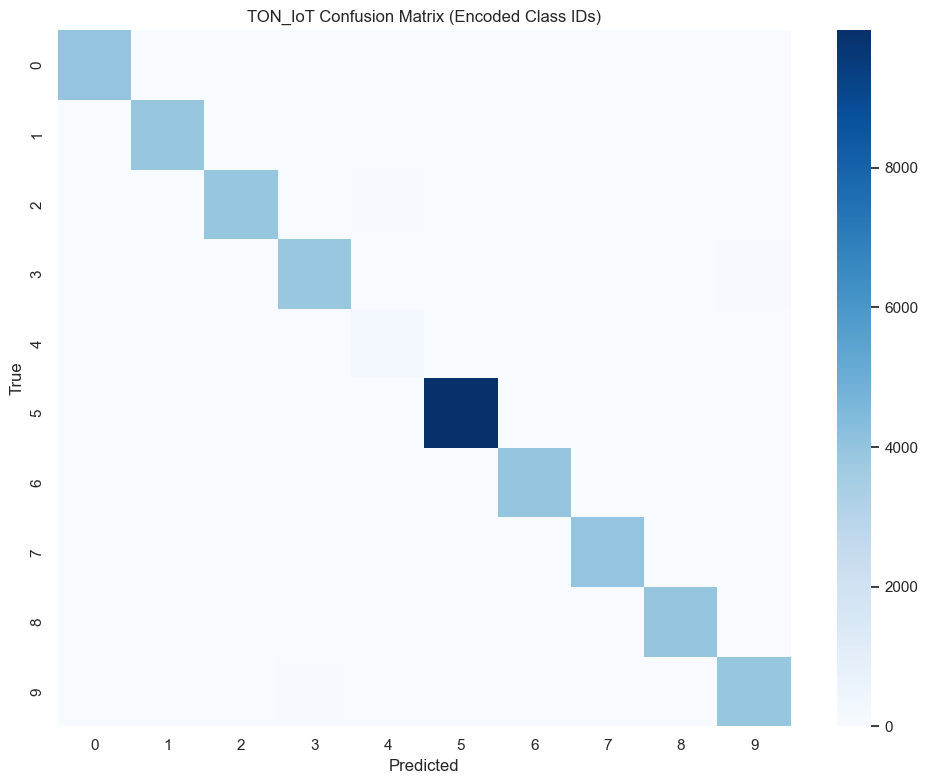

Macro ROC-AUC (OvR): 0.9996249029276063
Macro PR-AUC: 0.9790501642171169


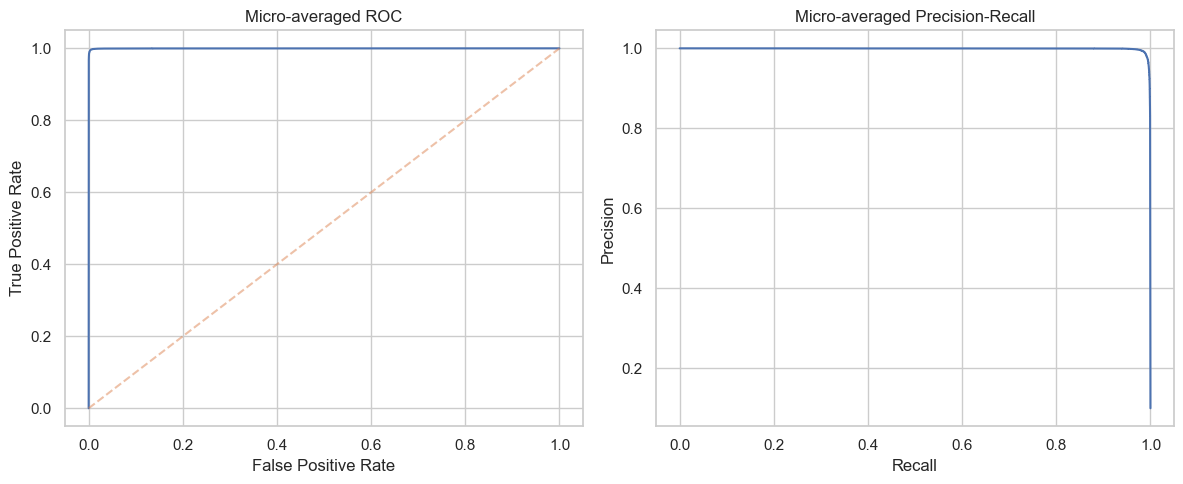

In [9]:
y_pred_test = best_model.predict(X_test)

print('Test weighted F1:', f1_score(y_test, y_pred_test, average='weighted', zero_division=0))
print('Test macro F1:', f1_score(y_test, y_pred_test, average='macro', zero_division=0))
print('Test balanced accuracy:', balanced_accuracy_score(y_test, y_pred_test))

report = classification_report(y_test, y_pred_test, target_names=y_encoder.classes_, zero_division=0)
print('\nClassification Report:\n')
print(report)

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap='Blues', cbar=True)
plt.title('TON_IoT Confusion Matrix (Encoded Class IDs)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC/PR (macro one-vs-rest) if probabilities are available
if hasattr(best_model, 'predict_proba'):
    y_proba_test = best_model.predict_proba(X_test)
    y_test_bin = label_binarize(y_test, classes=np.arange(len(y_encoder.classes_)))

    try:
        roc_auc_macro = roc_auc_score(y_test_bin, y_proba_test, average='macro', multi_class='ovr')
        pr_auc_macro = average_precision_score(y_test_bin, y_proba_test, average='macro')
        print('Macro ROC-AUC (OvR):', roc_auc_macro)
        print('Macro PR-AUC:', pr_auc_macro)

        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba_test.ravel())
        precision, recall, _ = precision_recall_curve(y_test_bin.ravel(), y_proba_test.ravel())

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(fpr, tpr)
        plt.plot([0, 1], [0, 1], '--', alpha=0.5)
        plt.title('Micro-averaged ROC')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')

        plt.subplot(1, 2, 2)
        plt.plot(recall, precision)
        plt.title('Micro-averaged Precision-Recall')
        plt.xlabel('Recall')
        plt.ylabel('Precision')

        plt.tight_layout()
        plt.savefig(f'{FIG_DIR}/roc_pr_curves.png', dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as ex:
        print('ROC/PR computation skipped:', ex)
else:
    y_proba_test = None
    print('Model has no predict_proba; ROC/PR skipped.')

## 9) Interpret Model with Feature Importance/SHAP
Compute global importances and try optional SHAP explanations if available.

,feature,importance
7,num__src_ip_bytes,0.140678
1,num__dst_port,0.105923
0,num__src_port,0.094894
9,num__dst_ip_bytes,0.069183
2,num__duration,0.059749
6,num__src_pkts,0.058268
8,num__dst_pkts,0.052664
3,num__src_bytes,0.050342
28,cat__conn_state_rej,0.037419
27,cat__conn_state_oth,0.034262


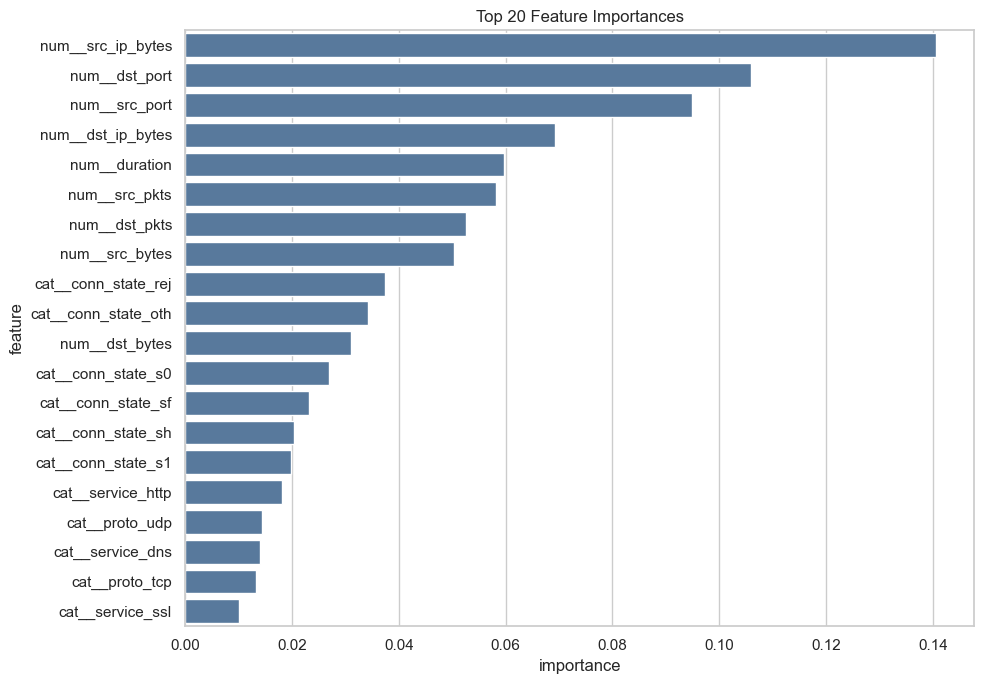

SHAP not available/skipped: No module named 'shap'


In [10]:
from sklearn.inspection import permutation_importance

prep_fitted = best_model.named_steps['prep']
model_fitted = best_model.named_steps['model']

feature_names = prep_fitted.get_feature_names_out()

if hasattr(model_fitted, 'feature_importances_'):
    importances = model_fitted.feature_importances_
else:
    # Fallback to permutation importance on validation subset
    perm = permutation_importance(best_model, X_val, y_val, n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
    importances = perm.importances_mean

fi = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi = fi.sort_values('importance', ascending=False).head(20)

display(fi)
plt.figure(figsize=(10, 7))
sns.barplot(data=fi, x='importance', y='feature', color='#4C78A8')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/top20_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Optional SHAP diagnostics
try:
    import shap
    sample_n = min(500, len(X_val))
    X_val_sample = X_val.sample(sample_n, random_state=RANDOM_STATE)
    X_val_pre = prep_fitted.transform(X_val_sample)

    if hasattr(model_fitted, 'predict_proba') and hasattr(model_fitted, 'estimators_'):
        explainer = shap.TreeExplainer(model_fitted)
        shap_values = explainer.shap_values(X_val_pre)
        if isinstance(shap_values, list):
            shap.summary_plot(shap_values[0], X_val_pre, show=False)
        else:
            shap.summary_plot(shap_values, X_val_pre, show=False)
        plt.tight_layout()
        plt.savefig(f'{FIG_DIR}/shap_summary.png', dpi=300, bbox_inches='tight')
        plt.show()
        print('SHAP summary generated.')
    else:
        print('SHAP skipped: best model type not tree-based.')
except Exception as ex:
    print('SHAP not available/skipped:', ex)

## 10) Persist Artifacts for Reuse
Save preprocessing+model pipeline, label encoder, schema metadata, and metrics for reproducible deployment.

In [11]:
metrics_summary = {
    'best_baseline_name': best_baseline_name,
    'test_f1_weighted': float(f1_score(y_test, y_pred_test, average='weighted', zero_division=0)),
    'test_f1_macro': float(f1_score(y_test, y_pred_test, average='macro', zero_division=0)),
    'test_balanced_accuracy': float(balanced_accuracy_score(y_test, y_pred_test)),
    'target_column': target_col,
    'n_classes': int(len(y_encoder.classes_)),
}

artifact_paths = {
    'model_pipeline': f'{ARTIFACT_DIR}/ton_iot_model_pipeline.joblib',
    'label_encoder': f'{ARTIFACT_DIR}/ton_iot_label_encoder.joblib',
    'metadata': f'{ARTIFACT_DIR}/ton_iot_metadata.json',
    'baseline_table': f'{ARTIFACT_DIR}/baseline_metrics.csv',
}

joblib.dump(best_model, artifact_paths['model_pipeline'])
joblib.dump(y_encoder, artifact_paths['label_encoder'])
baseline_df.to_csv(artifact_paths['baseline_table'], index=False)

metadata = {
    'data_path': DATA_PATH,
    'target_column': target_col,
    'classes': y_encoder.classes_.tolist(),
    'feature_columns': X.columns.tolist(),
    'metrics_summary': metrics_summary,
    'artifact_paths': artifact_paths,
}

with open(artifact_paths['metadata'], 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print('Saved artifacts:')
for k, v in artifact_paths.items():
    print(f'- {k}: {v}')
print('\nMetrics summary:', metrics_summary)

Saved artifacts:
- model_pipeline: models/ton_iot/ton_iot_model_pipeline.joblib
- label_encoder: models/ton_iot/ton_iot_label_encoder.joblib
- metadata: models/ton_iot/ton_iot_metadata.json
- baseline_table: models/ton_iot/baseline_metrics.csv

Metrics summary: {'best_baseline_name': 'RandomForest', 'test_f1_weighted': 0.9889271546027687, 'test_f1_macro': 0.9627094156172851, 'test_balanced_accuracy': 0.9820264354066985, 'target_column': 'type', 'n_classes': 10}
